In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load the dataset
avocado= pd.read_csv("C:/Users/Khaled/Documents/avocado.csv")
avocado.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
#select the variables
avocado_price=avocado[["Date", "AveragePrice"]]
avocado_price.head()

,Date,AveragePrice
0,12/27/2015,1.33
1,12/20/2015,1.35
2,12/13/2015,0.93
3,12/6/2015,1.08
4,11/29/2015,1.28


In [5]:
#Data Cleaning
avocado_price.info()
avocado_price.describe()
avocado_price.isna().sum()
avocado_price.duplicated()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  str    
 1   AveragePrice  18249 non-null  float64
dtypes: float64(1), str(1)
memory usage: 444.7 KB


0        False
1        False
2        False
3        False
4        False
         ...  
18244     True
18245    False
18246    False
18247    False
18248    False
Length: 18249, dtype: bool

In [6]:
avocado_price = avocado_price.drop_duplicates()
avocado_price.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
18243    False
18245    False
18246    False
18247    False
18248    False
Length: 12298, dtype: bool

In [7]:
avocado_price.columns

avocado_price.columns = avocado_price.columns.str.lower().str.strip()
avocado_price.columns

Index(['date', 'averageprice'], dtype='str')

In [8]:
# Convert to datetime
avocado_price['date'] = pd.to_datetime(avocado_price['date'])

avocado_price['day'] = avocado_price['date'].dt.day
avocado_price['month'] = avocado_price['date'].dt.month
avocado_price['year'] = avocado_price['date'].dt.year

print(avocado_price.head())


        date  averageprice  day  month  year
0 2015-12-27          1.33   27     12  2015
1 2015-12-20          1.35   20     12  2015
2 2015-12-13          0.93   13     12  2015
3 2015-12-06          1.08    6     12  2015
4 2015-11-29          1.28   29     11  2015


In [9]:
#set the date column as the index
avocado_price = avocado_price.set_index("date")
avocado_price.head()

,averageprice,day,month,year
date,,,,
2015-12-27,1.33,27,12,2015
2015-12-20,1.35,20,12,2015
2015-12-13,0.93,13,12,2015
2015-12-06,1.08,6,12,2015
2015-11-29,1.28,29,11,2015


Given that the dataset spans four years, the time series will be resampled to a monthly frequency to establish consistent intervals. This ensures equal spacing between observations, which is essential for robust time series analysis and improves the reliability of downstream modeling.

In [10]:
avocado_price_year = avocado_price["averageprice"].resample("ME").agg(["mean"])
avocado_price_year.head()
avocado_price_year.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39 entries, 2015-01-31 to 2018-03-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    39 non-null     float64
dtypes: float64(1)
memory usage: 624.0 bytes


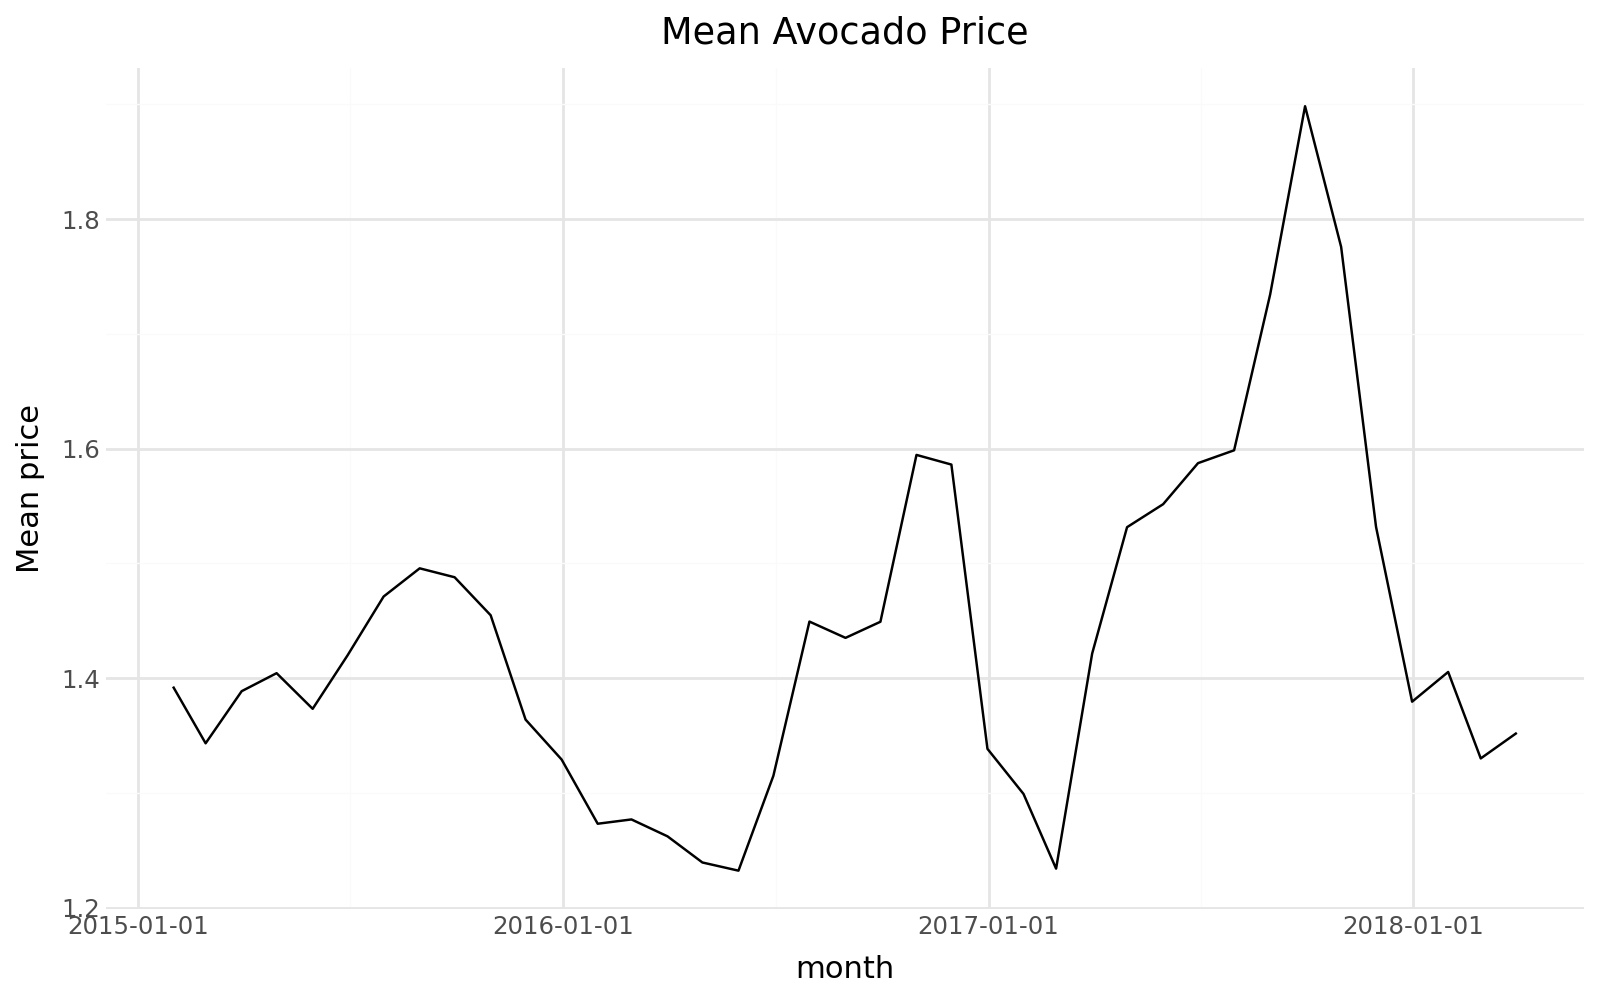

In [11]:
from plotnine import *
(ggplot(avocado_price_year, aes("avocado_price_year.index", "mean"))
+ geom_line()
+ theme_minimal()
+ theme(figure_size = (8, 5)) 
+ labs(x = "month",
      y = "Mean price",
      title = "Mean Avocado Price"))

Linearity

In [12]:
avocado_price_year["shift"] = avocado_price_year["mean"].shift(1)
avocado_price_year.head()

,mean,shift
date,,
2015-01-31,1.392596,NaN
2015-02-28,1.343179,1.392596
2015-03-31,1.388603,1.343179
2015-04-30,1.404291,1.388603
2015-05-31,1.373228,1.404291


C:\Users\Khaled\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
C:\Users\Khaled\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


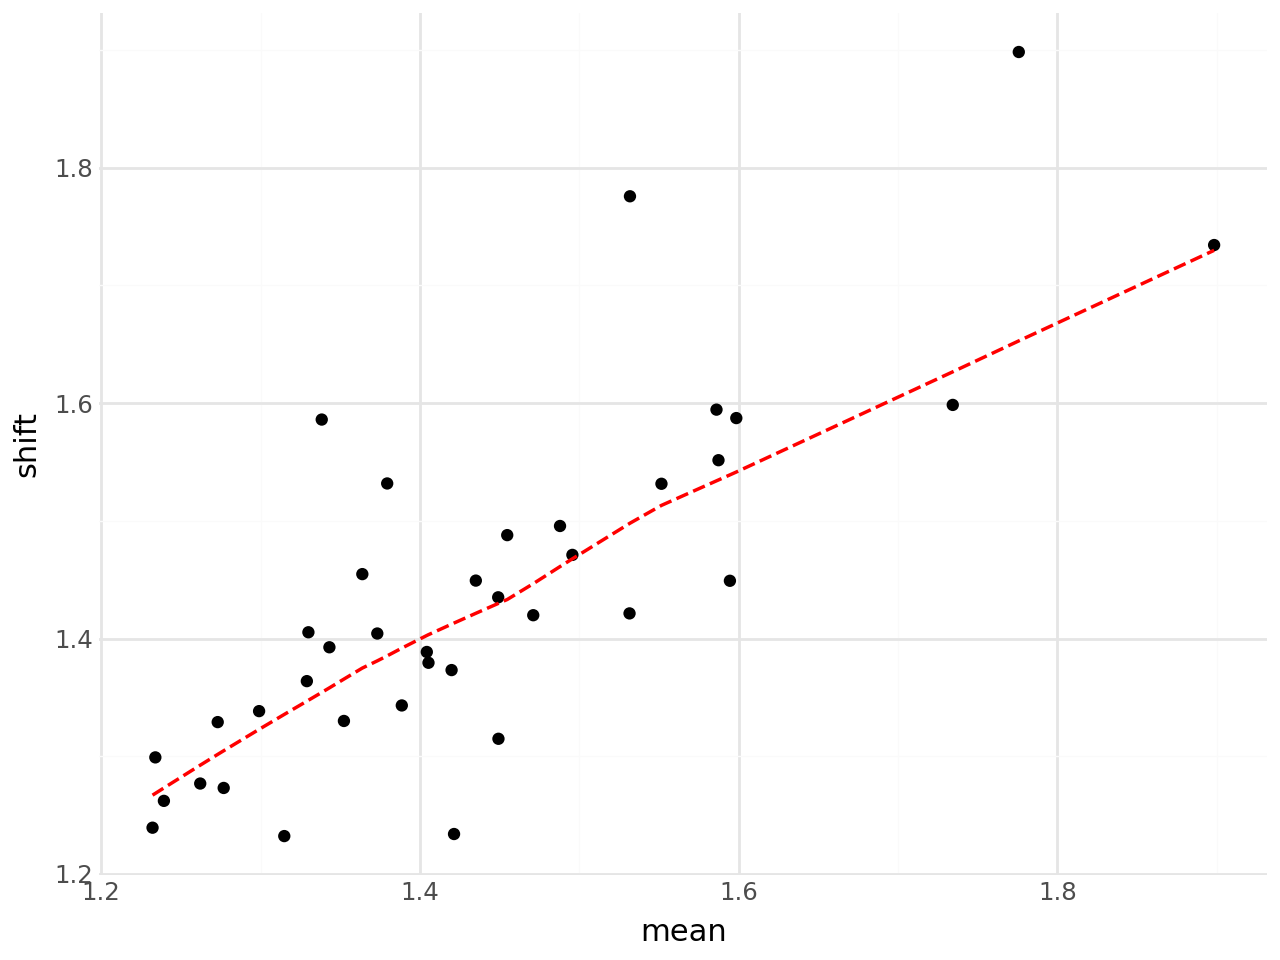

In [13]:
(ggplot(avocado_price_year, aes("mean", "shift"))
+ geom_point()
+ geom_smooth(linetype = "--", size = 0.7, color = "red") 
+ theme_minimal())

Stationarity

In [14]:
from statsmodels.tsa.stattools import adfuller

In [15]:
avocado2 = avocado_price_year[["mean"]]

In [17]:
avocado_adfuller = adfuller(avocado2)

pd.Series(avocado_adfuller[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -3.085345
p-value                                                                 0.027657
#Lags Used                                                                     1
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object

Autocorrelation plot

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

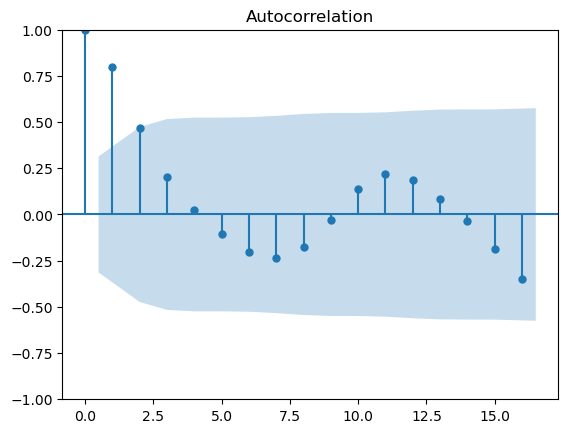

In [19]:
plot_acf(avocado2)

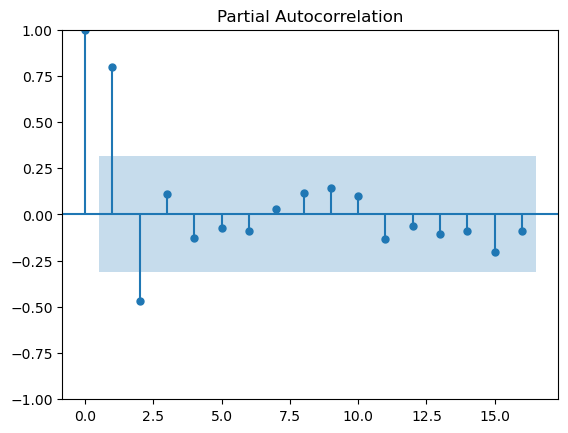

In [20]:
plot_pacf(avocado2)

Decomposition

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

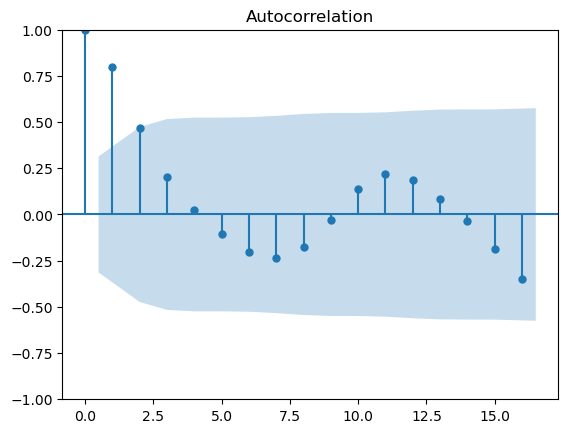

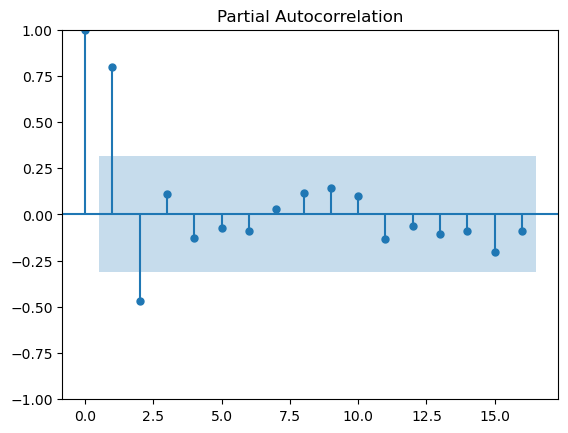

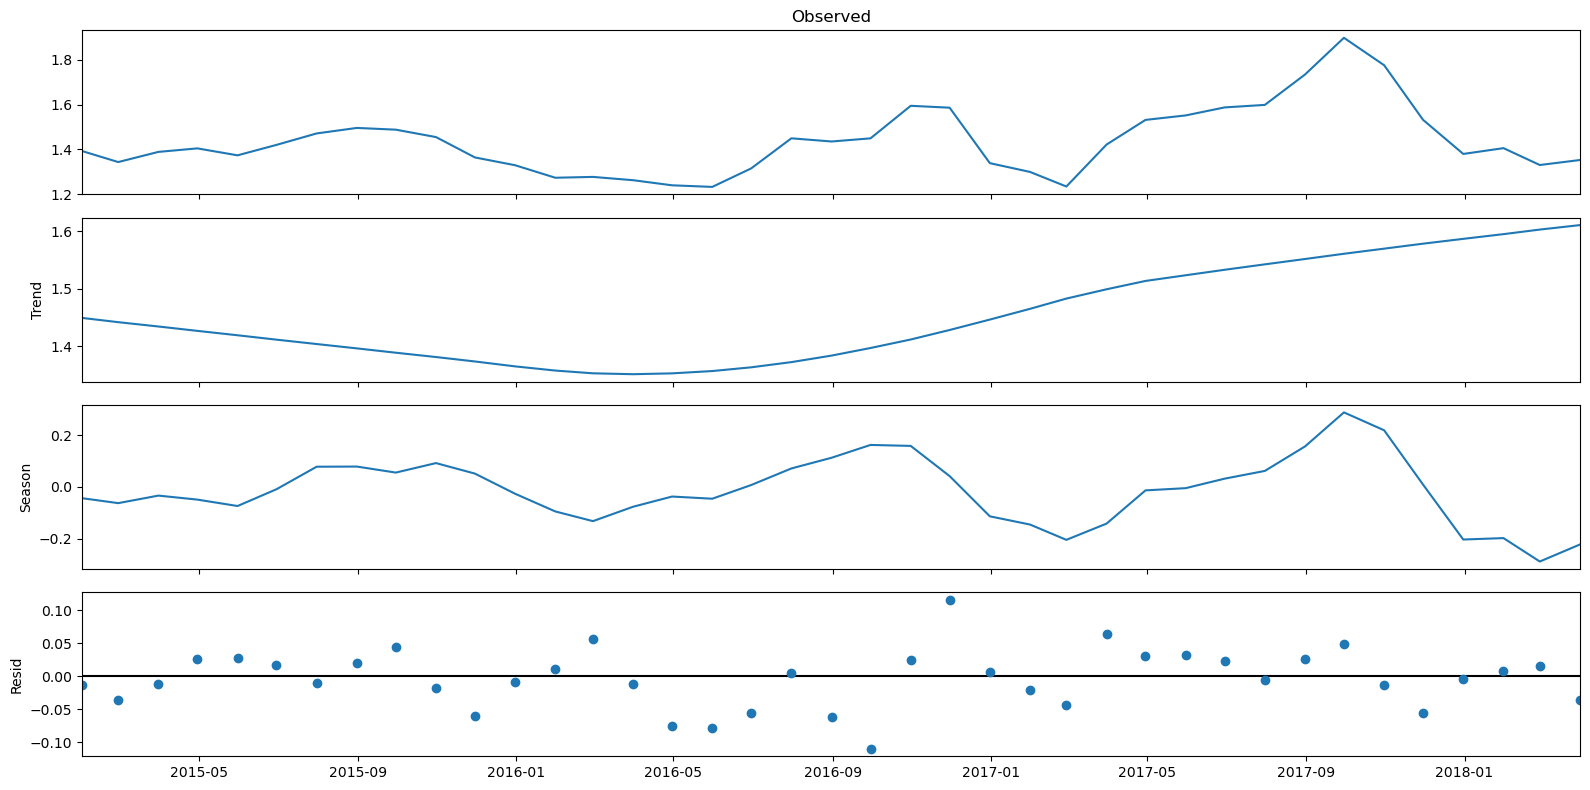

In [23]:
avocado_stl = STL(avocado2)
avocado_res = avocado_stl.fit()
result = avocado_res.plot()

result.set_size_inches(16, 8)

result.tight_layout()

plt.show()

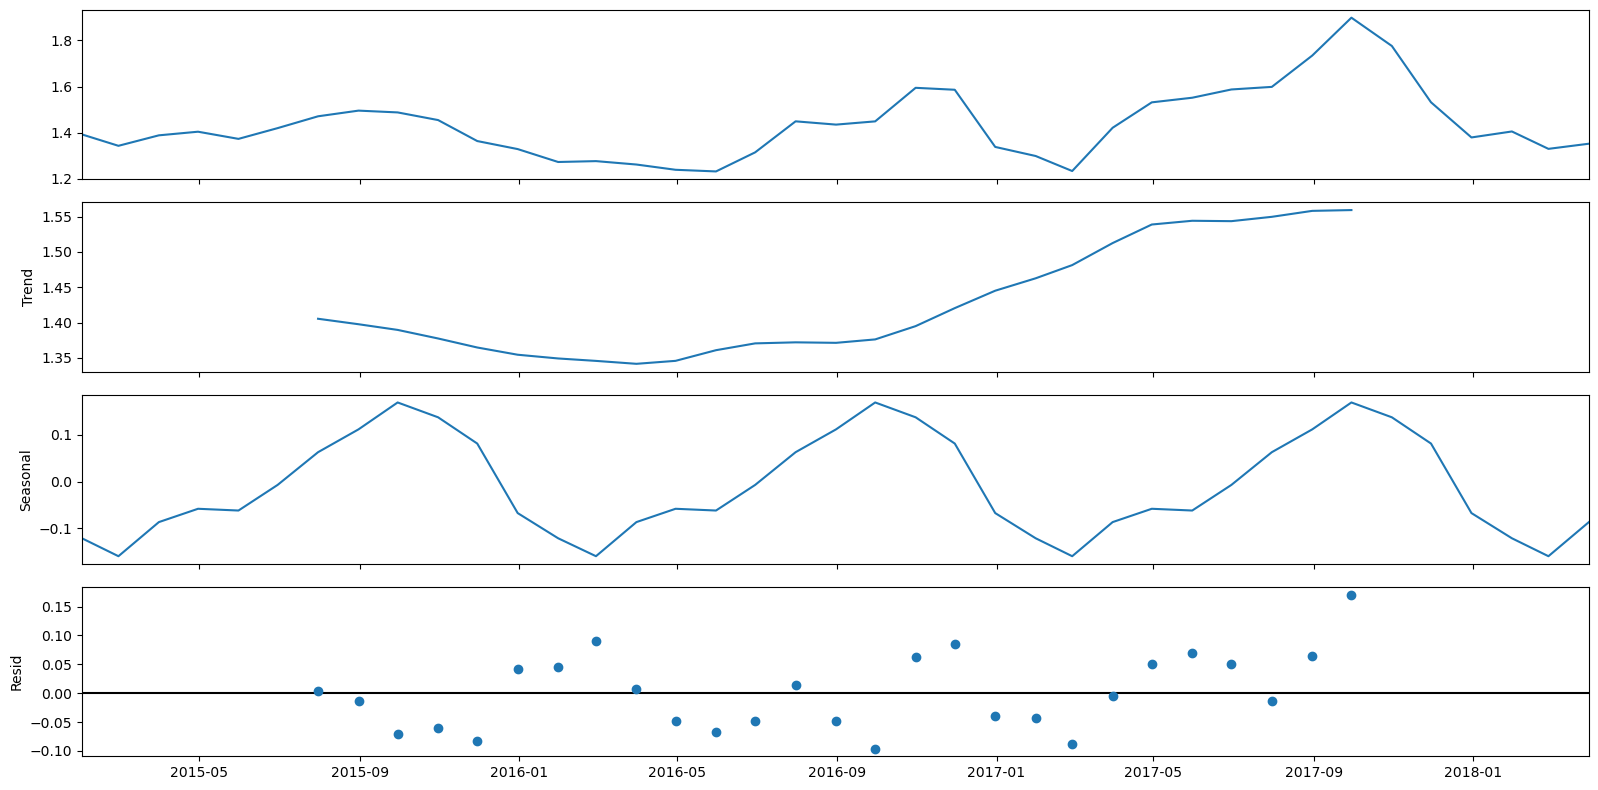

In [24]:
avocado2_season = seasonal_decompose(avocado2, period = 12)

avocado_plot = avocado2_season.plot()

avocado_plot.set_size_inches(16, 8)

avocado_plot.tight_layout()

plt.show()